# Imports Necessary Modules

In [6]:
from os import mkdir, listdir
from shutil import copyfile, rmtree
from random import sample
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt
import tensorflow as tf

# Data Paths

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
base_dir = '/content/Diseases'

train_dir = f'{base_dir}/train'
valid_dir = f'{base_dir}/valid'
test_dir = f'{base_dir}/test'

# Number of Images in each Class (Train, Validation, Test)

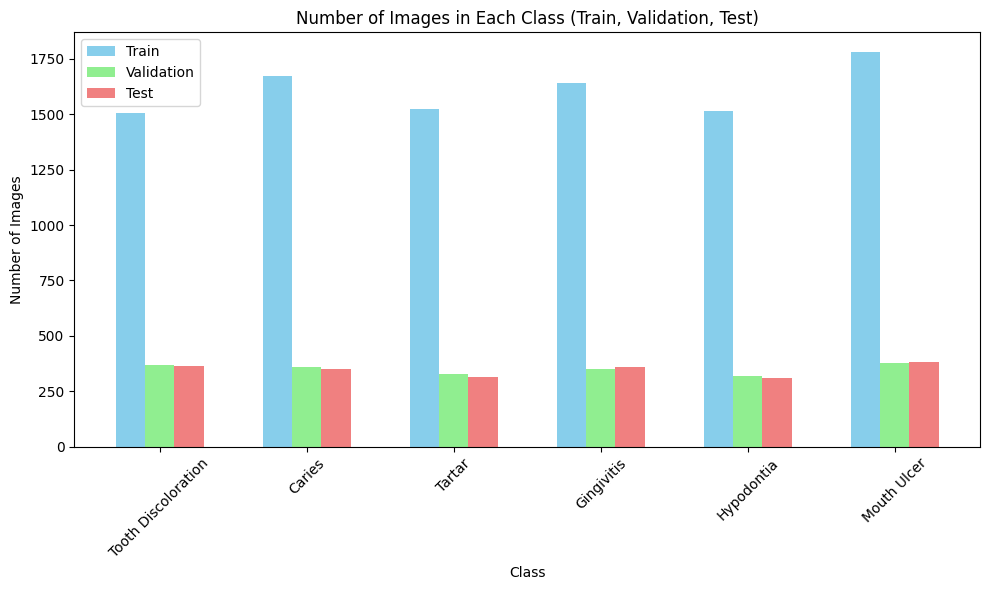

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

def count_images_in_classes(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
    return class_counts

train_counts = count_images_in_classes(train_dir)
valid_counts = count_images_in_classes(valid_dir)
test_counts = count_images_in_classes(test_dir)
all_classes = list(train_counts.keys())
train_values = [train_counts.get(cls, 0) for cls in all_classes]
valid_values = [valid_counts.get(cls, 0) for cls in all_classes]
test_values = [test_counts.get(cls, 0) for cls in all_classes]
x = np.arange(len(all_classes))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width, train_values, width, label='Train', color='skyblue')
plt.bar(x, valid_values, width, label='Validation', color='lightgreen')
plt.bar(x + width, test_values, width, label='Test', color='lightcoral')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Class (Train, Validation, Test)')
plt.xticks(x, all_classes, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Unique Image Sizes

In [9]:
import os
from PIL import Image
train_dir = '/content/Diseases/train'

unique_sizes = set()
for class_dir in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_dir)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            image_path = os.path.join(class_path, image_file)
            try:
                with Image.open(image_path) as img:
                    size = img.size  # (width, height)
                    unique_sizes.add(size)
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

print("Unique image sizes in the training data:")
sizes_str = ", ".join([f"({size[0]}, {size[1]})" for size in unique_sizes])
print(sizes_str)

Unique image sizes in the training data:
(287, 62), (315, 160), (601, 612), (234, 181), (201, 251), (158, 60), (612, 370), (276, 183), (347, 252), (612, 397), (612, 406), (303, 136), (325, 84), (283, 78), (280, 180), (268, 178), (311, 158), (272, 185), (257, 196), (525, 612), (408, 612), (284, 177), (173, 291), (380, 132), (612, 518), (175, 117), (298, 169), (233, 216), (612, 383), (376, 134), (280, 184), (387, 130), (325, 155), (293, 193), (612, 495), (612, 522), (221, 228), (612, 360), (330, 153), (276, 182), (339, 201), (271, 94), (363, 168), (225, 225), (415, 196), (612, 234), (612, 472), (336, 150), (282, 179), (396, 201), (612, 490), (274, 184), (270, 232), (319, 97), (194, 75), (612, 499), (202, 88), (294, 171), (277, 100), (255, 198), (185, 273), (286, 176), (337, 160), (197, 256), (612, 355), (298, 168), (244, 206), (213, 237), (379, 269), (291, 156), (321, 157), (581, 233), (378, 133), (149, 81), (428, 237), (317, 159), (228, 221), (200, 150), (330, 125), (232, 218), (215, 14

# Selecting Best image size based on aspect ratio

In [10]:
from collections import defaultdict
unique_sizes = list(unique_sizes)

def calculate_aspect_ratio(size):
    width, height = size
    return width / height

aspect_ratio_groups = defaultdict(list)
for size in unique_sizes:
    aspect_ratio = calculate_aspect_ratio(size)
    aspect_ratio_groups[aspect_ratio].append(size)

most_common_ratio_group = max(aspect_ratio_groups.items(), key=lambda item: len(item[1]))
best_size = most_common_ratio_group[1][0]
print(f"\nBest image size based on aspect ratio: {best_size}")


Best image size based on aspect ratio: (200, 150)


# Data Augmentation and Preprocessing with Resizing and Scaling

In [11]:
target_size = (200, 150)


train_generator = ImageDataGenerator(rescale=1/255,
                               rotation_range=20,
                               width_shift_range=0.2,
                               height_shift_range=0.2,
                               shear_range=0.2,
                               horizontal_flip=True,
                               zoom_range=0.2)

ready_train = train_generator.flow_from_directory(train_dir, target_size=target_size, batch_size=20 ,shuffle=True)


valid_test_generator = ImageDataGenerator(rescale=1/255)
ready_valid = valid_test_generator.flow_from_directory(valid_dir, target_size=target_size, batch_size=11,shuffle=False)
ready_test = valid_test_generator.flow_from_directory(test_dir, target_size=target_size, batch_size=11, shuffle=False)


Found 9635 images belonging to 6 classes.
Found 2109 images belonging to 6 classes.
Found 2082 images belonging to 6 classes.


# Sample Counts in Training, Validation, and Test Sets

In [12]:
train_images, train_labels = next(ready_train)
valid_images, valid_labels = next(ready_valid)
test_images, test_labels = next(ready_test)

print(f"Total training samples: {ready_train.samples}")
print(f"Total validation samples: {ready_valid.samples}")
print(f"Total test samples: {ready_test.samples}")

Total training samples: 9635
Total validation samples: 2109
Total test samples: 2082


# One Hot Encoding Labels

In [13]:
data_batch, labels_batch = next(ready_train)
print("First five labels in batch:")
for i in range(6):
    print(f"Label {i + 1}: {labels_batch[i]}")

First five labels in batch:
Label 1: [0. 1. 0. 0. 0. 0.]
Label 2: [0. 0. 0. 1. 0. 0.]
Label 3: [1. 0. 0. 0. 0. 0.]
Label 4: [0. 1. 0. 0. 0. 0.]
Label 5: [0. 0. 1. 0. 0. 0.]
Label 6: [0. 0. 0. 1. 0. 0.]


# Displaying Randomly Selected Images with Labels

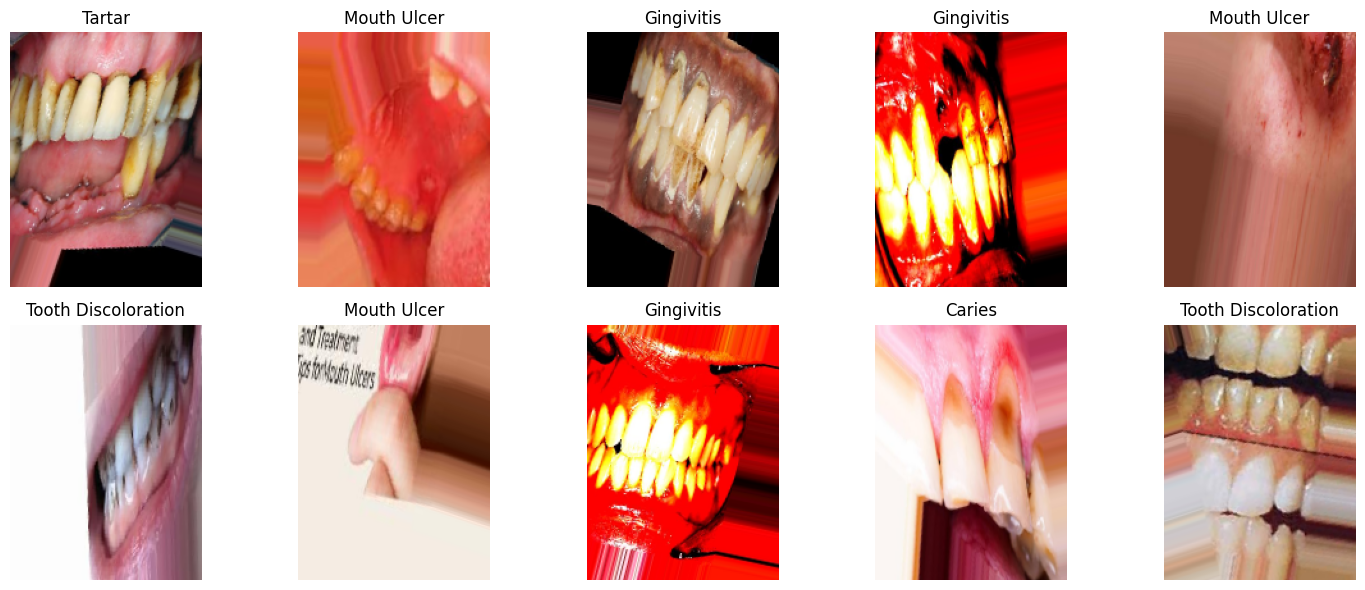

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_images_with_labels(generator, num_images=10, images_per_row=5):
    images, labels = next(generator)
    num_images_in_batch = images.shape[0]
    num_images = min(num_images, num_images_in_batch)
    num_rows = int(np.ceil(num_images / images_per_row))
    indices = np.random.choice(num_images_in_batch, num_images, replace=False)

    plt.figure(figsize=(images_per_row * 3, num_rows * 3))
    for i, index in enumerate(indices):
        plt.subplot(num_rows, images_per_row, i + 1)
        plt.imshow(images[index])
        plt.axis('off')
        label = np.argmax(labels[index])
        class_label = list(generator.class_indices.keys())[list(generator.class_indices.values()).index(label)]
        plt.title(class_label)

    plt.tight_layout()
    plt.show()

plot_images_with_labels(ready_train, num_images=10, images_per_row=5)


# CNN Model

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

CNN_Model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3),  activation='relu', input_shape=(200, 150, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(filters=128, kernel_size=(3,3),  activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(filters=256, kernel_size=(3,3),  activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization()
    ,
    layers.Flatten(),

    layers.Dense(1000, activation='elu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(255, activation='elu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='elu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='elu'),
    layers.BatchNormalization(),

    layers.Dense(6, activation='softmax')
])
CNN_Model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])



/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# EarlyStopping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)

# Training the Model

In [17]:
history = CNN_Model.fit(
    x=ready_train,
    callbacks=[early_stopping],
    epochs=35,
    validation_data=ready_valid,
    batch_size=32
)

Epoch 1/35


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


482/482 ━━━━━━━━━━━━━━━━━━━━ 115s 209ms/step - accuracy: 0.4341 - loss: 1.4612 - val_accuracy: 0.3983 - val_loss: 1.6451
Epoch 2/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 119s 182ms/step - accuracy: 0.5542 - loss: 1.1143 - val_accuracy: 0.5960 - val_loss: 0.9758
Epoch 3/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 90s 184ms/step - accuracy: 0.5946 - loss: 1.0140 - val_accuracy: 0.5510 - val_loss: 1.2247
Epoch 4/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 140s 180ms/step - accuracy: 0.6263 - loss: 0.9325 - val_accuracy: 0.5638 - val_loss: 1.2330
Epoch 5/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 143s 183ms/step - accuracy: 0.6606 - loss: 0.8526 - val_accuracy: 0.6562 - val_loss: 0.8073
Epoch 6/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 145s 187ms/step - accuracy: 0.6696 - loss: 0.8227 - val_accuracy: 0.6581 - val_loss: 0.8802
Epoch 7/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 88s 181ms/step - accuracy: 0.6879 - loss: 0.7910 - val_accuracy: 0.6581 - val_loss: 0.9385
Epoch 8/35
482/482 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.7035 - loss: 0.7534

# Model Summary

In [18]:
CNN_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 99, 74, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 36, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 23, 17, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 21, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 7, 256)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 10, 7, 256)          │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 17920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1000)                │      17,921,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 1000)                │           4,000 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 255)                 │         255,255 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 255)                 │           1,020 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 37,223,734 (142.00 MB)

 Trainable params: 18,609,939 (70.99 MB)

 Non-trainable params: 3,854 (15.05 KB)

 Optimizer params: 18,609,941 (70.99 MB)

# Save the Model

In [19]:
CNN_Model.save("Disease_CNN.h5")

# Evaluating the Model Performance

In [21]:
test_loss, test_acc = CNN_Model.evaluate(ready_test, verbose=2)
test_accuracy_percentage = test_acc * 100
print(f"test accuracy: {test_accuracy_percentage:.2f}%")

190/190 - 5s - 28ms/step - accuracy: 0.8372 - loss: 0.4395
test accuracy: 83.72%


# Visualizing Model Accuracy Over Epochs

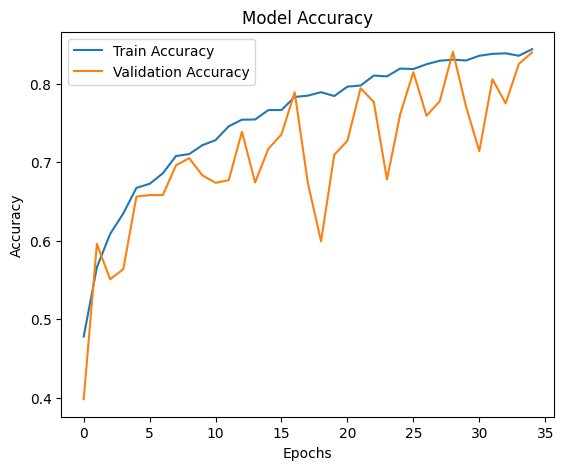

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Classification Report

In [23]:
import numpy as np
from sklearn.metrics import classification_report

Y_pred = CNN_Model.predict(ready_test)
y_pred = np.argmax(Y_pred, axis=1)
y_true = ready_test.classes

class_labels = list(ready_test.class_indices.keys())
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
Classification Report:
                     precision    recall  f1-score   support

             Caries       0.97      0.79      0.87       352
         Gingivitis       0.74      0.53      0.62       359
         Hypodontia       0.86      0.99      0.92       311
        Mouth Ulcer       0.95      0.99      0.97       381
             Tartar       0.62      0.86      0.72       316
Tooth Discoloration       0.93      0.88      0.90       363

           accuracy                           0.84      2082
          macro avg       0.84      0.84      0.83      2082
       weighted avg       0.85      0.84      0.83      2082



# Confusion Matrix

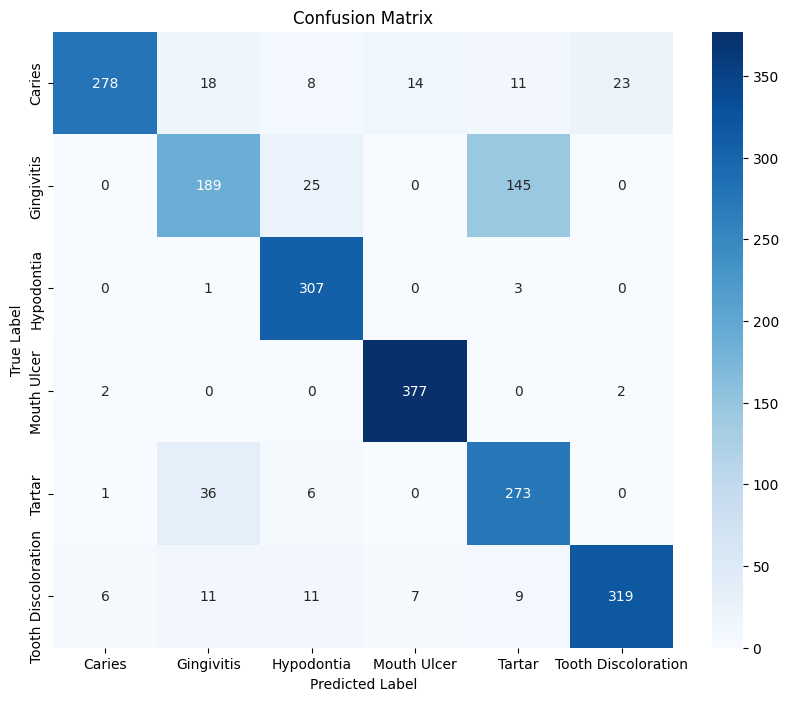

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Load Trained Model and Predict Disease Class from a New Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


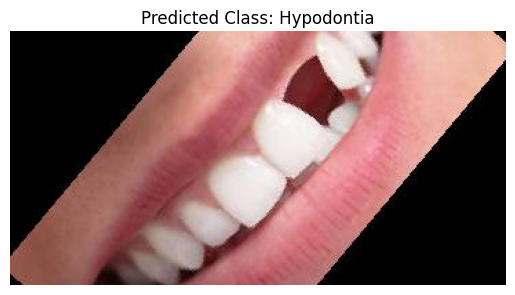

The predicted class is: Hypodontia


In [25]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

KerasModel = load_model('Disease_CNN.h5')
img_path = '/content/Diseases/test/Hypodontia/(1072).JPG'
img = image.load_img(img_path, target_size=(200, 150))
img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0) #(1, 200, 150, 3)
predicted_class = KerasModel.predict(img_array)
predicted_label = np.argmax(predicted_class, axis=1)
class_labels = ['Caries', 'Gingivitis', 'Hypodontia','Mouth Ulcer', 'Tartar', 'Tooth Discoloration']

predicted_class_name = class_labels[predicted_label[0]]
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted Class: {predicted_class_name}")
plt.axis('off')
plt.show()

print(f"The predicted class is: {predicted_class_name}")